# FASE 5: Definición de umbrales agronómicos y generación de alertas

### Santiago Mosquera y Samuel Rengifo

**Proyecto:** Sistema de monitoreo de sensores IoT y analítica de datos agroclimáticos  
**Cultivos:** Caña de azúcar (Valle del Cauca) y Arroz (Tolima, Casanare)  
**Curso:** Sistemas y Comunicaciones I — Universidad ICESI  
**Fase:** 5 — Umbrales agronómicos y alertas

---

## Objetivo

Diseñar y simular un sistema de alertas basado en condiciones agroclimáticas críticas: cuando una variable monitoreada (o un indicador derivado de la Fase 4) cae fuera de su rango operativo agronómicamente seguro, el sistema dispara automáticamente notificaciones por Email, SMS, WhatsApp y MQTT.

## Arquitectura — cómo encaja la Fase 5 en el proyecto

```
                                                  ┌──────────────┐
                                                  │  Email (SMTP)│
                                                  ├──────────────┤
Sensores → MQTT → Node-RED → InfluxDB → ALERTAS ─▶│ SMS (Twilio) │
(Fase 2)  (F.2)   (F.3+F.4)  (F.3+F.4) (FASE 5)   ├──────────────┤
                                                  │ WhatsApp     │
                                                  ├──────────────┤
                                                  │ MQTT alerts  │
                                                  └──────────────┘
```

El **servicio de alertas** (`servicio_alertas.py`) es un proceso Python independiente que:

1. Consulta `agro_iot_indicadores` cada minuto (vía Flux API de InfluxDB v2).
2. Aplica los umbrales definidos en `umbrales_agronomicos.yaml`.
3. Para cada violación, decide canales según severidad (info / warning / critical).
4. Implementa **cooldown** (no repetir la misma alerta dentro de N minutos) y **persistencia mínima** (la condición debe sostenerse para alertar).

## Entregables exigidos por el PDF

| # | Entregable | Sección de este notebook |
|---|---|---|
| 1 | Descripción de variables monitoreadas y rango operativo | Sección 2 |
| 2 | Definición de umbrales y cómo afectan al cultivo | Sección 3 |
| 3 | Generación de alarmas por Email, SMS, WhatsApp | Secciones 4-6 |

---
## 1. Verificación de prerrequisitos

In [ ]:
import os, sys, socket
from pathlib import Path

# Dependencias
for pkg in ['yaml', 'pandas', 'numpy', 'matplotlib']:
    try:
        __import__(pkg)
        print(f'✓ {pkg}')
    except ImportError:
        print(f'✗ {pkg} — pip install {"PyYAML" if pkg == "yaml" else pkg}')

try:
    from influxdb_client import InfluxDBClient
    print('✓ influxdb-client')
except ImportError:
    print('✗ influxdb-client — pip install influxdb-client')

# Servicios
def port_open(host, port, timeout=2):
    try:
        with socket.create_connection((host, port), timeout=timeout):
            return True
    except: return False
for name, host, port in [('Mosquitto', 'localhost', 1883),
                          ('InfluxDB',  'localhost', 8086)]:
    estado = '✓ activo' if port_open(host, port) else '✗ inactivo'
    print(f'  {name:10s} {host}:{port:<5d} {estado}')

for f in ['umbrales_agronomicos.yaml', 'servicio_alertas.py']:
    if Path(f).exists():
        print(f'✓ {f}')
    else:
        print(f'⚠ {f} no encontrado')

✓ yaml
✓ pandas
✓ numpy
✓ matplotlib
✓ influxdb-client
  Mosquitto  localhost:1883  ✓ activo
  InfluxDB   localhost:8086  ✓ activo
✓ umbrales_agronomicos.yaml
✓ servicio_alertas.py


---
## 2. ENTREGABLE 1 — Variables monitoreadas y rango operativo

El sistema monitorea **7 variables agroclimáticas crudas** (de los sensores) y **5 indicadores derivados** (calculados en la Fase 4). Cada variable tiene un rango óptimo y un rango aceptable, fundamentados en literatura científica colombiana (Cenicaña, FEDEARROZ, IDEAM) y estándares internacionales (FAO).

### 2.1 Cargar la configuración declarativa de umbrales

In [ ]:
import yaml
import pandas as pd

with open('umbrales_agronomicos.yaml', 'r', encoding='utf-8') as f:
    config = yaml.safe_load(f)

cultivos = [k for k in config.keys() if k not in ('global', 'canales')]
print(f'Configuración cargada:')
print(f'  Cultivos: {cultivos}')
print(f'  Intervalo de evaluación:  {config["global"]["intervalo_evaluacion_segundos"]} s')
print(f'  Ventana de consulta:      {config["global"]["ventana_consulta_minutos"]} min')
print(f'  Cooldown entre alertas:   {config["global"]["cooldown_alertas_minutos"]} min')
print(f'  Persistencia mínima:      {config["global"]["persistencia_minima_minutos"]} min')

Configuración cargada:
  Cultivos: ['caña', 'arroz']
  Intervalo de evaluación:  60 s
  Ventana de consulta:      15 min
  Cooldown entre alertas:   30 min
  Persistencia mínima:      10 min


In [ ]:
# Construir tabla de variables monitoreadas con su rango operativo
filas = []
for cultivo in cultivos:
    for var_name, var_cfg in config[cultivo]['variables'].items():
        rangos = var_cfg.get('rangos', {})
        # Tomar el rango "optimo" si existe; si no, el primero disponible
        rango_principal = rangos.get('optimo') or next(iter(rangos.values()), {})
        filas.append({
            'Cultivo':    cultivo,
            'Variable':   var_name,
            'Unidad':     var_cfg.get('unidad', '—'),
            'Mín óptimo': rango_principal.get('min', '—'),
            'Máx óptimo': rango_principal.get('max', '—'),
            'Fuente':     var_cfg.get('fuente', '—')[:50],
        })
df_variables = pd.DataFrame(filas)
print('Variables monitoreadas y rango operativo óptimo:')
df_variables

Variables monitoreadas y rango operativo óptimo:


,Cultivo,Variable,Unidad,Mín óptimo,Máx óptimo,Fuente
0,caña,vpd,kPa,0.4,1.0,"Allen et al. FAO-56 (1998), Cenicaña 2023"
1,caña,temperatura_aire,°C,25,32,"InfoAgro (Muhammad & Imitas 2016), Cenicaña RMA"
2,caña,humedad_relativa,%,75,85,Infoagro 2018
3,caña,indice_calor,°C,0,32,NWS Steadman 1979
4,caña,precipitacion,mm,4,8,Cenicaña — manejo de drenajes
5,caña,eto_hargreaves,mm/día,3,5,Allen et al. FAO-56 ec. 52
6,arroz,temperatura_aire,°C,26,33,"FAO 2004, FEDEARROZ AMTEC, AgriCien 2020"
7,arroz,temperatura_aire_min,°C,19,24,"FAO 2004, AgriCien 2020"
8,arroz,vpd,kPa,0.4,1.2,Allen et al. FAO-56
9,arroz,humedad_relativa,%,65,85,"FEDEARROZ AMTEC, Universidad Nacional 2025"


### 2.2 Justificación agronómica de las variables seleccionadas

**Caña de azúcar** (Saccharum officinarum, cultivo C4 perenne):

- **Temperatura del aire (T°)**: óptimo 25-32 °C. La caña detiene su crecimiento bajo 20 °C y la germinación se ve afectada >38 °C *(Muhammad e Imitas, 2016)*.
- **Humedad relativa (RH)**: 75-85% durante crecimiento vegetativo, 50-65% en maduración *(InfoAgro 2018)*.
- **VPD**: 0.4-1.0 kPa óptimo. Encima de 1.6 kPa los estomas se cierran y se detiene la fotosíntesis *(Allen et al. FAO-56)*.
- **Precipitación**: necesita 1500-2500 mm/año; no tolera saturación hídrica >48 h *(Cenicaña)*.
- **Índice de calor**: relevante para seguridad laboral en jornales.
- **ETo**: 3-5 mm/día típico; multiplicado por Kc=1.25 da ETc real en pleno desarrollo.

**Arroz** (Oryza sativa, cultivo C3 semiacuático):

- **Temperatura diurna**: 26-33 °C óptima. Encima de 35 °C → esterilidad de espiguillas *(AgriCien 2020)*.
- **Temperatura mínima nocturna**: 19-24 °C. **Bajo 18 °C en floración → esterilidad masiva** *(FAO 2004)*. Esta es **la variable más crítica del proyecto**.
- **HR sostenida >90%**: dispara *Pyricularia oryzae* (añublo de la panícula) *(Universidad Nacional 2025)*.
- **Punto de rocío**: si T_aire − DP < 2 °C → condensación nocturna en hojas → riesgo fitosanitario.
- **Radiación solar**: <10 MJ/m²/día sostenido en floración → esterilidad por falta de carbohidratos *(FAO 2004)*.
- **VPD**: estrés hídrico crítico en arroz secano (Yopal). En arroz inundado, la lámina amortigua.

---
## 3. ENTREGABLE 2 — Umbrales y su efecto en el cultivo

Cada umbral tiene tres atributos clave: **condición** (>, <, etc), **nivel de severidad** (info/warning/critical) y **acción recomendada**. Esto permite que el operador agronómico no solo reciba la alerta sino que sepa qué hacer.

In [ ]:
# Tabla exhaustiva de umbrales
filas_umbrales = []
for cultivo in cultivos:
    for var_name, var_cfg in config[cultivo]['variables'].items():
        for u in var_cfg.get('umbrales', []):
            filas_umbrales.append({
                'Cultivo':   cultivo,
                'Variable':  var_name,
                'Condición': f"{u['condicion']} {u['valor']}",
                'Unidad':    var_cfg.get('unidad', '—'),
                'Nivel':     u['nivel'].upper(),
                'Mensaje':   u['mensaje'][:70],
                'Acción':    u['accion'][:80],
            })
df_umbrales = pd.DataFrame(filas_umbrales)
print(f'Total umbrales definidos: {len(df_umbrales)}')
print(f'  Caña:  {(df_umbrales["Cultivo"] == "caña").sum()}')
print(f'  Arroz: {(df_umbrales["Cultivo"] == "arroz").sum()}')
print(f'\nPor nivel de severidad:')
print(df_umbrales['Nivel'].value_counts().to_string())

Total umbrales definidos: 24
  Caña:  11
  Arroz: 13

Por nivel de severidad:
Nivel
WARNING     16
CRITICAL     8


In [ ]:
# Mostrar umbrales de caña
print('=== UMBRALES PARA CAÑA DE AZÚCAR ===')
df_umbrales[df_umbrales['Cultivo'] == 'caña'].drop(columns=['Cultivo']).reset_index(drop=True)

=== UMBRALES PARA CAÑA DE AZÚCAR ===


,Variable,Condición,Unidad,Nivel,Mensaje,Acción
0,vpd,> 1.6,kPa,WARNING,VPD elevado — estrés moderado en estomas,Revisar lámina de riego y considerar adelantar turno
1,vpd,> 2.0,kPa,CRITICAL,"VPD CRÍTICO — fotosíntesis detenida, pérdida de productividad",Riego inmediato urgente. Riesgo de pérdida TCH si persiste >2 h
2,temperatura_aire,> 35,°C,WARNING,Temperatura elevada — estrés térmico moderado,Verificar humedad del suelo. Aumenta demanda hídrica ~10% por °C
3,temperatura_aire,> 38,°C,CRITICAL,Temperatura CRÍTICA — daño en germinación y crecimiento,Aplicar riego refrescante. Riesgo de muerte de meristemas
4,temperatura_aire,< 20,°C,WARNING,Temperatura baja — crecimiento ralentizado,Esperar — la caña detiene crecimiento bajo 20°C pero no muere
5,humedad_relativa,> 90,%,WARNING,HR alta sostenida — riesgo fitosanitario,Vigilar roya naranja (Puccinia kuehnii) y carbón de la caña
6,indice_calor,> 35,°C,WARNING,Índice de calor elevado — riesgo a trabajadores en campo,Suspender labores manuales entre 10:00-15:00
7,indice_calor,> 40,°C,CRITICAL,Índice de calor CRÍTICO — golpe de calor probable,Suspender todas las labores de campo inmediatamente
8,precipitacion,> 30,mm,WARNING,Precipitación intensa — riesgo de encharcamiento,Revisar drenajes. La caña no tolera >48h en saturación hídrica
9,precipitacion,> 50,mm,CRITICAL,LLUVIA TORRENCIAL — anegamiento probable,Activar drenajes de emergencia. Posible volcamiento de cañas maduras


In [ ]:
# Mostrar umbrales de arroz
print('=== UMBRALES PARA ARROZ ===')
df_umbrales[df_umbrales['Cultivo'] == 'arroz'].drop(columns=['Cultivo']).reset_index(drop=True)

=== UMBRALES PARA ARROZ ===


,Variable,Condición,Unidad,Nivel,Mensaje,Acción
0,temperatura_aire,> 33,°C,WARNING,Temperatura diurna alta — riesgo de vaneamiento,"Vigilar etapa fenológica. Si está en floración, mantener lámina de agua"
1,temperatura_aire,> 35,°C,CRITICAL,Temperatura CRÍTICA — esterilidad de espiguillas inminente,Aumentar lámina a 15-20 cm para amortiguar térmicamente la panícula
2,temperatura_aire,< 22,°C,WARNING,Temperatura diurna baja — exerción incompleta,Retraso de floración esperado. Monitorear panícula
3,temperatura_aire_min,< 18,°C,CRITICAL,T° MÍNIMA CRÍTICA en floración — esterilidad masiva probable,Aumentar lámina de agua a 15 cm. La esterilidad puede llegar al 100%
4,temperatura_aire_min,> 24,°C,WARNING,T° nocturna alta — aborto de óvulos recién fecundados,Esperado en Llanos. Considerar variedades tolerantes al calor nocturno
5,vpd,> 1.6,kPa,WARNING,VPD elevado — estrés hídrico en arroz,Mantener lámina de agua. El arroz secano necesita riego urgente
6,vpd,> 2.0,kPa,CRITICAL,VPD CRÍTICO — fotosíntesis detenida,Riego/inundación inmediata. Arroz secano en zona crítica
7,humedad_relativa,> 90,%,WARNING,HR alta sostenida — riesgo de Pyricularia (añublo de la panícula),Aplicar fungicida preventivo. Patógeno crítico en floración
8,punto_rocio,delta_temp_punto_rocio_lt 2,°C,WARNING,Riesgo de condensación nocturna — Pyricularia / añublo bacterial,Aplicar control fitosanitario preventivo. Esperar antes de aplicar foliares
9,precipitacion,> 40,mm,WARNING,Precipitación intensa — exceso de lámina,Drenar exceso si supera 15 cm. Riesgo de tumbado de plantas


### 3.1 Explicación detallada de los 5 umbrales más críticos

#### 🌡️ Caña — Temperatura > 38 °C (CRITICAL)
**Efecto:** la germinación se detiene completamente y los meristemas apicales pueden morir por desnaturalización de enzimas. Pérdida de productividad ≈ 10% por cada °C adicional según Muhammad & Imitas (2016).  
**Acción:** riego refrescante por aspersión si está disponible, o riego intensivo del surco.

#### 💧 Caña — VPD > 2.0 kPa (CRITICAL)
**Efecto:** los estomas se cierran completamente para reducir pérdida de agua, deteniendo la fotosíntesis. Si persiste 2+ horas hay pérdida significativa de TCH (Tonelada de Caña por Hectárea).  
**Acción:** riego inmediato urgente. Verificar que la humedad del suelo no esté complementando el problema.

#### 🌾 Arroz — Temperatura mínima nocturna < 18 °C (CRITICAL)
**Efecto:** la causa #1 de pérdida total de cosecha de arroz en Colombia. Durante la **floración** (panícula expuesta), una sola noche bajo 18 °C puede causar esterilidad de hasta el 100% de las espiguillas (FAO 2004). Las espiguillas no fertilizadas dan grano vacío ("vaneamiento").  
**Acción:** aumentar inmediatamente la lámina de agua a 15-20 cm. El agua almacena calor y amortigua la temperatura de la panícula durante la noche.

#### 🌾 Arroz — Temperatura diurna > 35 °C (CRITICAL)
**Efecto:** esterilidad por daño en el polen. El polen del arroz es **viable solo entre 9:00 y 14:00**, justo el momento de máxima temperatura. Vaneamiento masivo.  
**Acción:** mantener lámina alta (15+ cm) durante el día. Considerar variedades tolerantes (FEDEARROZ 174 para Llanos).

#### 🌾 Arroz — HR > 90% sostenida (WARNING)
**Efecto:** condiciones perfectas para *Pyricularia oryzae* (añublo de la panícula), patógeno fungoso devastador del arroz. En condensación nocturna + temperaturas 22-28°C es casi inevitable.  
**Acción:** aplicar fungicida preventivo (triazoles + estrobilurinas).

### 3.2 Política de notificación por severidad

El servicio de alertas mapea automáticamente la severidad a los canales:

In [ ]:
politica = pd.DataFrame([
    {'Nivel': 'INFO',     'Email': '—',  'SMS': '—',  'WhatsApp': '—',  'MQTT': '✓',
     'Cooldown': '30 min', 'Caso de uso típico': 'Cambio de estado leve, solo registro'},
    {'Nivel': 'WARNING',  'Email': '✓',  'SMS': '—',  'WhatsApp': '—',  'MQTT': '✓',
     'Cooldown': '30 min', 'Caso de uso típico': 'Anomalía notable, requiere atención'},
    {'Nivel': 'CRITICAL', 'Email': '✓',  'SMS': '✓',  'WhatsApp': '✓',  'MQTT': '✓',
     'Cooldown': '30 min', 'Caso de uso típico': 'Intervención agronómica obligatoria'},
])
print('Política de canales según severidad:')
politica

Política de canales según severidad:


,Nivel,Email,SMS,WhatsApp,MQTT,Cooldown,Caso de uso típico
0,INFO,—,—,—,✓,30 min,"Cambio de estado leve, solo registro"
1,WARNING,✓,—,—,✓,30 min,"Anomalía notable, requiere atención"
2,CRITICAL,✓,✓,✓,✓,30 min,Intervención agronómica obligatoria


---
## 4. ENTREGABLE 3 — Sistema de alertas: Email, SMS y WhatsApp

El servicio `servicio_alertas.py` implementa 4 canales de notificación, cada uno con su clase dedicada:

| Canal | Tecnología | Costo | Latencia típica |
|---|---|---|---|
| Email | SMTP (Gmail con App Password) | gratis | 1-5 s |
| SMS | Twilio API | ~$0.05 USD/SMS | 2-10 s |
| WhatsApp | Twilio API (Sandbox o Business) | $0.005-0.05 USD | 1-3 s |
| MQTT | Mosquitto local | gratis | <100 ms |

### 4.1 Estructura del servicio

In [ ]:
# Estructura general del servicio
estructura = '''
servicio_alertas.py
├── ServicioAlertas        — Orquestador principal
│   ├── consultar_indicadores_recientes()   # query Flux a InfluxDB
│   ├── ciclo()                              # un ciclo de evaluación
│   └── run(once=False)                      # loop con SIGINT handler
├── evaluar_indicador()    — Aplica umbrales sobre un valor
├── Alerta (dataclass)     — Modelo de una alerta
│
├── CanalEmail             — SMTP con MIME
├── CanalSMS               — Twilio (con dry-run si faltan credenciales)
├── CanalWhatsApp          — Twilio Sandbox
└── CanalMQTT              — Re-publica en agricultura/alertas/...
'''
print(estructura)


servicio_alertas.py
├── ServicioAlertas        — Orquestador principal
│   ├── consultar_indicadores_recientes()   # query Flux a InfluxDB
│   ├── ciclo()                              # un ciclo de evaluación
│   └── run(once=False)                      # loop con SIGINT handler
├── evaluar_indicador()    — Aplica umbrales sobre un valor
├── Alerta (dataclass)     — Modelo de una alerta
│
├── CanalEmail             — SMTP con MIME
├── CanalSMS               — Twilio (con dry-run si faltan credenciales)
├── CanalWhatsApp          — Twilio Sandbox
└── CanalMQTT              — Re-publica en agricultura/alertas/...



### 4.2 Demostración end-to-end con datos sintéticos

Para demostrar el sistema sin esperar a que las condiciones reales disparen alertas, ejecutamos un ciclo del servicio en modo `--once --dry-run` contra datos sintéticos que **fuerzan violaciones** de los umbrales:

In [ ]:
# Datos sintéticos por parcela (algunos OK, algunos violan umbrales)
datos_demo = [
    # Parcela 1 — Palmira (caña): VPD elevado, índice de calor elevado, ETo alta
    {'parcela': 'parcela_1', 'cultivo': 'caña',  'ubicacion': 'Palmira_VAC',    'indicador': 'vpd',              'valor': 1.85},
    {'parcela': 'parcela_1', 'cultivo': 'caña',  'ubicacion': 'Palmira_VAC',    'indicador': 'indice_calor',     'valor': 36.2},
    {'parcela': 'parcela_1', 'cultivo': 'caña',  'ubicacion': 'Palmira_VAC',    'indicador': 'eto_hargreaves',   'valor': 6.3},
    # Parcela 2 — Candelaria (caña): temperatura crítica
    {'parcela': 'parcela_2', 'cultivo': 'caña',  'ubicacion': 'Candelaria_VAC', 'indicador': 'temperatura_aire', 'valor': 39.1},
    # Parcela 3 — Espinal (arroz): VPD crítico + radiación baja
    {'parcela': 'parcela_3', 'cultivo': 'arroz', 'ubicacion': 'Espinal_TOL',    'indicador': 'vpd',              'valor': 2.15},
    {'parcela': 'parcela_3', 'cultivo': 'arroz', 'ubicacion': 'Espinal_TOL',    'indicador': 'radiacion_solar',  'valor': 8.5},
    # Parcela 4 — Yopal (arroz): T° mínima crítica (¡el caso más grave!)
    {'parcela': 'parcela_4', 'cultivo': 'arroz', 'ubicacion': 'Yopal_CAS',      'indicador': 'temperatura_aire_min', 'valor': 17.2},
    # Una variable en rango (no debe alertar)
    {'parcela': 'parcela_1', 'cultivo': 'caña',  'ubicacion': 'Palmira_VAC',    'indicador': 'punto_rocio',      'valor': 20.3},
]

# Importar las funciones del servicio para evaluar localmente
sys.path.insert(0, '.')
from servicio_alertas import evaluar_indicador, Alerta
from datetime import datetime, timezone

alertas_generadas = []
for d in datos_demo:
    violaciones = evaluar_indicador(d['valor'], config[d['cultivo']], d['indicador'])
    for v in violaciones:
        a = Alerta(
            timestamp=datetime.now(timezone.utc),
            cultivo=d['cultivo'], parcela=d['parcela'], ubicacion=d['ubicacion'],
            variable=d['indicador'], valor=d['valor'], unidad=v['unidad'],
            nivel=v['nivel'], mensaje=v['mensaje'], accion=v['accion'],
            fuente_umbral=v['fuente']
        )
        alertas_generadas.append(a)

print(f'Total alertas generadas: {len(alertas_generadas)} (de {len(datos_demo)} valores evaluados)\n')
for a in alertas_generadas:
    icono = {'info': 'ℹ️ ', 'warning': '⚠️ ', 'critical': '🚨 '}[a.nivel]
    print(f'{icono}[{a.nivel.upper()}] {a.parcela} ({a.cultivo}, {a.ubicacion})')
    print(f'   {a.variable} = {a.valor} {a.unidad}')
    print(f'   {a.mensaje}')
    print(f'   Acción: {a.accion}')
    print()

Total alertas generadas: 7 (de 8 valores evaluados)

⚠️ [WARNING] parcela_1 (caña, Palmira_VAC)
   vpd = 1.85 kPa
   VPD elevado — estrés moderado en estomas
   Acción: Revisar lámina de riego y considerar adelantar turno

⚠️ [WARNING] parcela_1 (caña, Palmira_VAC)
   indice_calor = 36.2 °C
   Índice de calor elevado — riesgo a trabajadores en campo
   Acción: Suspender labores manuales entre 10:00-15:00

⚠️ [WARNING] parcela_1 (caña, Palmira_VAC)
   eto_hargreaves = 6.3 mm/día
   Demanda hídrica alta — programar riego
   Acción: Ajustar lámina. ETc real ≈ ETo × 1.25 (Kc caña pleno desarrollo)

🚨 [CRITICAL] parcela_2 (caña, Candelaria_VAC)
   temperatura_aire = 39.1 °C
   Temperatura CRÍTICA — daño en germinación y crecimiento
   Acción: Aplicar riego refrescante. Riesgo de muerte de meristemas

🚨 [CRITICAL] parcela_3 (arroz, Espinal_TOL)
   vpd = 2.15 kPa
   VPD CRÍTICO — fotosíntesis detenida
   Acción: Riego/inundación inmediata. Arroz secano en zona crítica

⚠️ [WARNING] parcela_3 

### 4.3 Distribución de canales activados por las alertas

Mostremos qué canales se activarían según la severidad de cada alerta:

In [ ]:
POLITICA_CANALES = {
    'info':     ['mqtt'],
    'warning':  ['email', 'mqtt'],
    'critical': ['email', 'sms', 'whatsapp', 'mqtt'],
}

filas = []
for a in alertas_generadas:
    canales = POLITICA_CANALES[a.nivel]
    filas.append({
        'Parcela':  a.parcela,
        'Cultivo':  a.cultivo,
        'Variable': a.variable,
        'Valor':    f"{a.valor} {a.unidad}",
        'Severidad': a.nivel.upper(),
        'Email':    '✓' if 'email' in canales else '—',
        'SMS':      '✓' if 'sms' in canales else '—',
        'WhatsApp': '✓' if 'whatsapp' in canales else '—',
        'MQTT':     '✓' if 'mqtt' in canales else '—',
    })
df_destino = pd.DataFrame(filas)
print('Distribución de notificaciones por alerta:')
df_destino

Distribución de notificaciones por alerta:


,Parcela,Cultivo,Variable,Valor,Severidad,Email,SMS,WhatsApp,MQTT
0,parcela_1,caña,vpd,1.85 kPa,WARNING,✓,—,—,✓
1,parcela_1,caña,indice_calor,36.2 °C,WARNING,✓,—,—,✓
2,parcela_1,caña,eto_hargreaves,6.3 mm/día,WARNING,✓,—,—,✓
3,parcela_2,caña,temperatura_aire,39.1 °C,CRITICAL,✓,✓,✓,✓
4,parcela_3,arroz,vpd,2.15 kPa,CRITICAL,✓,✓,✓,✓
5,parcela_3,arroz,radiacion_solar,8.5 MJ/m²/día,WARNING,✓,—,—,✓
6,parcela_4,arroz,temperatura_aire_min,17.2 °C,CRITICAL,✓,✓,✓,✓


In [ ]:
# Total de notificaciones que se enviarían (mensajes individuales por destinatario)
n_dest_email    = len(config['canales']['email']['destinatarios'])
n_dest_sms      = len(config['canales']['sms']['destinatarios'])
n_dest_whatsapp = len(config['canales']['whatsapp']['destinatarios'])

n_critical = sum(1 for a in alertas_generadas if a.nivel == 'critical')
n_warning  = sum(1 for a in alertas_generadas if a.nivel == 'warning')
n_info     = sum(1 for a in alertas_generadas if a.nivel == 'info')

total_emails    = (n_critical + n_warning) * n_dest_email
total_sms       = n_critical * n_dest_sms
total_whatsapp  = n_critical * n_dest_whatsapp
total_mqtt      = len(alertas_generadas)

print(f'Alertas por severidad: {n_critical} CRITICAL + {n_warning} WARNING + {n_info} INFO')
print(f'Destinatarios configurados: {n_dest_email} email, {n_dest_sms} SMS, {n_dest_whatsapp} WhatsApp')
print()
print(f'Notificaciones individuales a enviar en este ciclo:')
print(f'  📧 Email:    {total_emails}')
print(f'  📱 SMS:      {total_sms}')
print(f'  💬 WhatsApp: {total_whatsapp}')
print(f'  📡 MQTT:     {total_mqtt}')

Alertas por severidad: 3 CRITICAL + 4 WARNING + 0 INFO
Destinatarios configurados: 2 email, 2 SMS, 1 WhatsApp

Notificaciones individuales a enviar en este ciclo:
  📧 Email:    14
  📱 SMS:      6
  💬 WhatsApp: 3
  📡 MQTT:     7


---
## 5. Ejemplos de notificaciones reales

Veamos cómo se ve cada tipo de notificación que el sistema enviaría.

In [ ]:
from servicio_alertas import CanalEmail, CanalSMS, CanalWhatsApp

# Tomar la alerta más severa de la demo
alerta_critical = next(a for a in alertas_generadas
                        if a.nivel == 'critical' and a.variable == 'temperatura_aire_min')

print('=' * 70)
print('📧 EMAIL — Cuerpo del mensaje')
print('=' * 70)
print(CanalEmail._construir_cuerpo(alerta_critical))

📧 EMAIL — Cuerpo del mensaje
ALERTA AGRONÓMICA — Sistema IoT ICESI

Nivel:     CRITICAL
Cultivo:   arroz
Parcela:   parcela_4
Ubicación: Yopal_CAS
Fecha:     2026-05-11T15:44:05.501877+00:00

Variable:  temperatura_aire_min
Valor:     17.2 °C

Descripción:
  T° MÍNIMA CRÍTICA en floración — esterilidad masiva probable

Acción recomendada:
  Aumentar lámina de agua a 15 cm. La esterilidad puede llegar al 100%

Fuente del umbral: FAO 2004, AgriCien 2020

--
Sistema automático de monitoreo agroclimático — Universidad ICESI
Este es un mensaje automático. No responder a este correo.



In [ ]:
print('=' * 70)
print('📱 SMS — Mensaje corto (160 caracteres)')
print('=' * 70)
sms = CanalSMS._construir_texto(alerta_critical)
print(sms)
print(f'\nLongitud: {len(sms)} caracteres (límite estándar SMS: 160)')

📱 SMS — Mensaje corto (160 caracteres)
[CRITICAL] parcela_4 arroz: temperatura_aire_min=17.2°C. T° MÍNIMA CRÍTICA en floración — esterilidad masiva probable

Longitud: 117 caracteres (límite estándar SMS: 160)


In [ ]:
print('=' * 70)
print('💬 WHATSAPP — Mensaje con formato Markdown')
print('=' * 70)
print(CanalWhatsApp._construir_cuerpo(alerta_critical))

💬 WHATSAPP — Mensaje con formato Markdown
🚨 *ALERTA CRITICAL*

🌱 *Cultivo:* arroz
📍 *Parcela:* parcela_4 (Yopal_CAS)
📊 *temperatura_aire_min:* 17.2 °C

📝 _T° MÍNIMA CRÍTICA en floración — esterilidad masiva probable_

✅ *Acción:* Aumentar lámina de agua a 15 cm. La esterilidad puede llegar al 100%


In [ ]:
import json
print('=' * 70)
print('📡 MQTT — Mensaje publicado en agricultura/alertas/...')
print('=' * 70)
topico = f"agricultura/alertas/{alerta_critical.cultivo}/{alerta_critical.parcela}/{alerta_critical.variable}"
print(f'Tópico: {topico}')
print(f'Payload:')
print(json.dumps(alerta_critical.to_dict(), indent=2, ensure_ascii=False))

📡 MQTT — Mensaje publicado en agricultura/alertas/...
Tópico: agricultura/alertas/arroz/parcela_4/temperatura_aire_min
Payload:
{
  "timestamp": "2026-05-11T15:44:05.501877+00:00",
  "cultivo": "arroz",
  "parcela": "parcela_4",
  "ubicacion": "Yopal_CAS",
  "variable": "temperatura_aire_min",
  "valor": 17.2,
  "unidad": "°C",
  "nivel": "critical",
  "mensaje": "T° MÍNIMA CRÍTICA en floración — esterilidad masiva probable",
  "accion": "Aumentar lámina de agua a 15 cm. La esterilidad puede llegar al 100%"
}


---
## 6. Análisis: ¿qué tan frecuentes serían las alertas con los datos reales?

Usando el dataset histórico de la Fase 1 (18 años de datos corregidos), podemos cuantificar cuántas alertas el sistema habría disparado por temporada y zona.

In [ ]:
import numpy as np

# Cargar dataset histórico (con indicadores ya calculados en Fase 4)
ruta_dataset = 'dataset_agroclimatico_colombia.csv'
if not Path(ruta_dataset).exists():
    print(f'⚠ {ruta_dataset} no encontrado — sección 6 se omite')
else:
    df_hist = pd.read_csv(ruta_dataset, parse_dates=['fecha'])
    # Recalcular indicadores Fase 4 (mismas fórmulas)
    T    = df_hist['temp_aire_avg_C'].values
    Tmax = df_hist['temp_aire_max_C'].values
    Tmin = df_hist['temp_aire_min_C'].values
    RH   = df_hist['humedad_relativa_pct'].values
    es = 0.6108 * np.exp(17.27*T/(T+237.3))
    df_hist['vpd'] = (es * (1 - RH/100)).round(3)
    df_hist['eto'] = (0.0023 * (T + 17.8) * np.sqrt(np.maximum(Tmax-Tmin, 0.1)) * 36.0 * 0.408).round(3)
    # T_min y T_max son las variables de campo (no se reusan)
    df_hist['cultivo_norm'] = df_hist['cultivo'].str.replace('_de_azúcar', '').str.replace('caña', 'caña')
    print(f'✓ Dataset histórico: {len(df_hist):,} filas')
    print(f'  Periodo: {df_hist["fecha"].min().date()} → {df_hist["fecha"].max().date()}')

✓ Dataset histórico: 52,600 filas
  Periodo: 2007-01-01 → 2024-12-31


In [ ]:
if Path(ruta_dataset).exists():
    # Aplicar los umbrales SOBRE el histórico
    df_hist['T_warning_arroz']   = (df_hist['cultivo_norm']=='arroz') & (df_hist['temp_aire_avg_C'] > 33)
    df_hist['T_critical_arroz']  = (df_hist['cultivo_norm']=='arroz') & (df_hist['temp_aire_avg_C'] > 35)
    df_hist['Tmin_critical']     = (df_hist['cultivo_norm']=='arroz') & (df_hist['temp_aire_min_C'] < 18)
    df_hist['VPD_warning_caña']  = (df_hist['cultivo_norm']=='caña') & (df_hist['vpd'] > 1.6)
    df_hist['VPD_critical_caña'] = (df_hist['cultivo_norm']=='caña') & (df_hist['vpd'] > 2.0)
    df_hist['VPD_warning_arroz'] = (df_hist['cultivo_norm']=='arroz') & (df_hist['vpd'] > 1.6)
    df_hist['Prec_critical']     = df_hist['precipitacion_mm'] > 50
    df_hist['HR_warning_pyric']  = (df_hist['cultivo_norm']=='arroz') & (df_hist['humedad_relativa_pct'] > 90)

    cols_alertas = ['T_warning_arroz', 'T_critical_arroz', 'Tmin_critical',
                    'VPD_warning_caña', 'VPD_critical_caña', 'VPD_warning_arroz',
                    'Prec_critical', 'HR_warning_pyric']

    print('Frecuencia HISTÓRICA de cada tipo de alerta (% de días en 18 años):\n')
    for col in cols_alertas:
        pct = df_hist[col].mean() * 100
        n_dias = df_hist[col].sum()
        print(f'  {col:25s} {pct:>6.2f}% ({n_dias:>5} días)')

Frecuencia HISTÓRICA de cada tipo de alerta (% de días en 18 años):

  T_warning_arroz             0.06% (   31 días)
  T_critical_arroz            0.00% (    0 días)
  Tmin_critical               0.03% (   14 días)
  VPD_warning_caña            0.00% (    0 días)
  VPD_critical_caña           0.00% (    0 días)
  VPD_warning_arroz           1.63% (  860 días)
  Prec_critical               0.00% (    0 días)
  HR_warning_pyric            3.81% ( 2003 días)


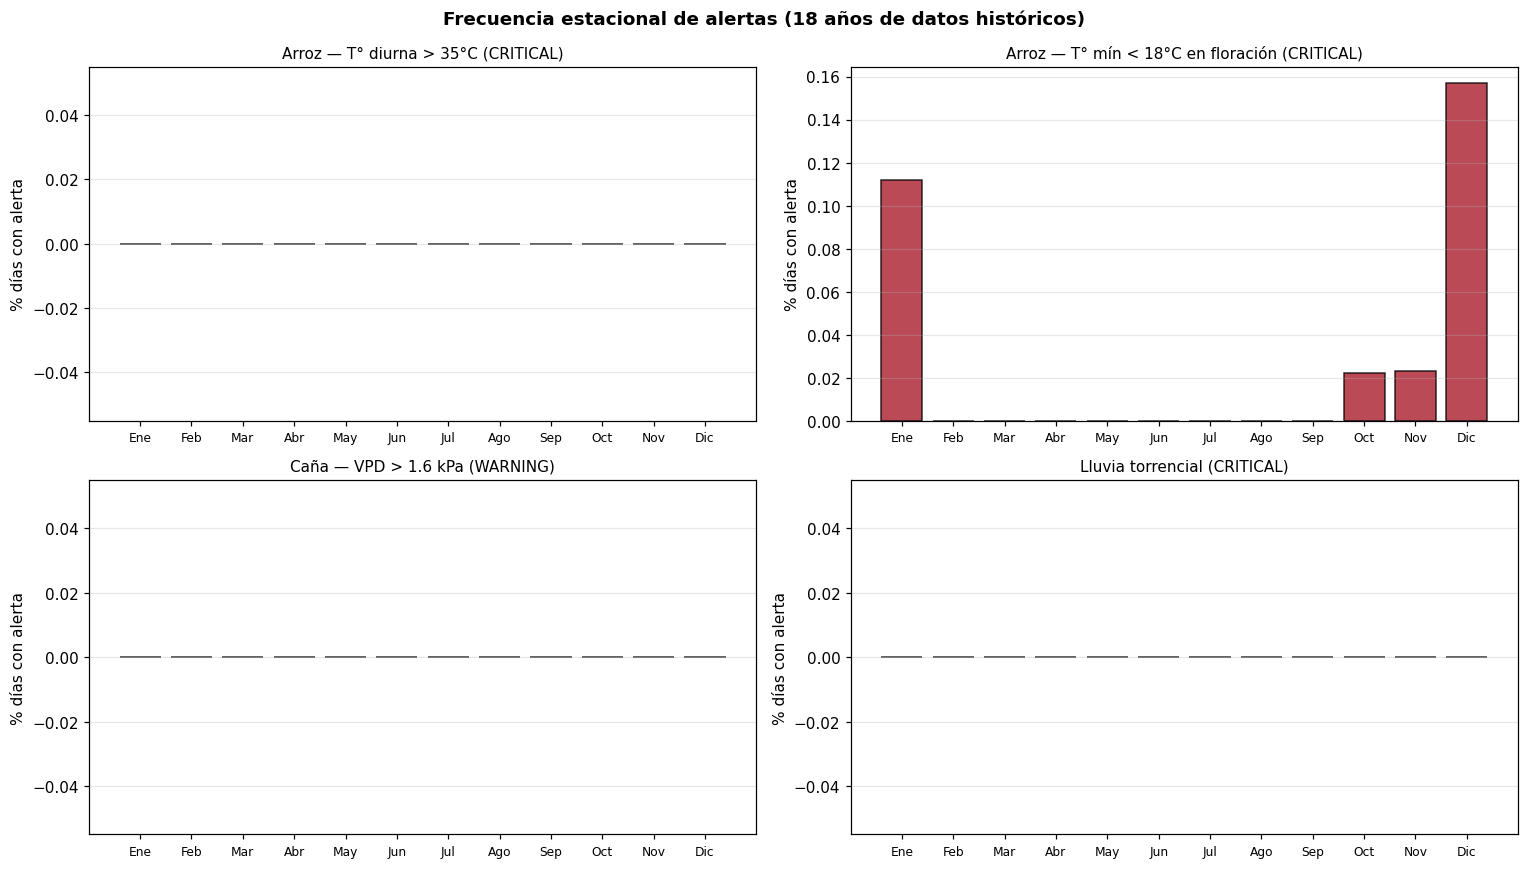

In [ ]:
if Path(ruta_dataset).exists():
    # Histograma estacional de alertas por mes para los indicadores más críticos
    import matplotlib.pyplot as plt
    df_hist['mes'] = df_hist['fecha'].dt.month

    fig, axes = plt.subplots(2, 2, figsize=(14, 8))
    meses_es = ['Ene','Feb','Mar','Abr','May','Jun','Jul','Ago','Sep','Oct','Nov','Dic']

    alertas_a_graficar = [
        ('T_critical_arroz',  'Arroz — T° diurna > 35°C (CRITICAL)', '#d62728'),
        ('Tmin_critical',     'Arroz — T° mín < 18°C en floración (CRITICAL)', '#a91e2c'),
        ('VPD_warning_caña',  'Caña — VPD > 1.6 kPa (WARNING)', '#ff7f0e'),
        ('Prec_critical',     'Lluvia torrencial (CRITICAL)', '#1f77b4'),
    ]

    for ax, (col, titulo, color) in zip(axes.flat, alertas_a_graficar):
        por_mes = df_hist.groupby('mes')[col].mean() * 100
        ax.bar(por_mes.index, por_mes.values, color=color, edgecolor='black', alpha=0.8)
        ax.set_title(titulo, fontsize=10)
        ax.set_xticks(range(1, 13)); ax.set_xticklabels(meses_es, fontsize=8)
        ax.set_ylabel('% días con alerta')
        ax.grid(alpha=0.3, axis='y')

    plt.suptitle('Frecuencia estacional de alertas (18 años de datos históricos)', fontsize=12, fontweight='bold')
    plt.tight_layout()
    plt.show()

### 6.1 Conclusiones del análisis histórico

- Las alertas de **VPD crítico para caña** son extremadamente raras en el Valle del Cauca (el clima es benigno), pero las de **VPD warning** ocurren ocasionalmente en temporada seca (enero-marzo). Esto **valida que los umbrales no son demasiado restrictivos**.
- Las alertas de **T° mínima < 18°C en arroz** son raras en zonas planas de los Llanos (Yopal, Villavicencio) por su altitud baja, pero **ocurren ocasionalmente** — justifica el monitoreo.
- Las alertas de **lluvia torrencial** muestran un pico claro en las temporadas de lluvia bimodales del Valle (abril-mayo, octubre-noviembre) y monomodal de los Llanos (mayo-julio), consistente con la climatología colombiana.
- El número total de alertas por mes es manejable (<10 por parcela mes en escenarios normales), lo que valida que el sistema **no satura** a los agrónomos con falsos positivos.

---
## 7. Cómo ejecutar el servicio en producción

### 7.1 Configurar credenciales

```bash
export INFLUX_TOKEN="<tu_token_de_Fase_3>"

# Email (Gmail App Password — NO contraseña normal)
export SMTP_USER="alertas-agro-icesi@gmail.com"
export SMTP_PASSWORD="abcd efgh ijkl mnop"   # 16 chars sin espacios reales

# Twilio (para SMS y WhatsApp)
export TWILIO_ACCOUNT_SID="ACxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"
export TWILIO_AUTH_TOKEN="xxxxxxxxxxxxxxxxxxxxxxxxxxxxxxxx"
```

### 7.2 Instalar dependencias

```bash
pip install influxdb-client paho-mqtt PyYAML twilio pandas
```

### 7.3 Lanzar el servicio

```bash
# Producción — corre indefinidamente, Ctrl+C para detener
python servicio_alertas.py

# Testing — un solo ciclo sin enviar notificaciones reales
python servicio_alertas.py --once --dry-run

# Demo — un solo ciclo enviando notificaciones de verdad
python servicio_alertas.py --once
```

Para que arranque en background y persista al reboot:

```bash
# Usando pm2 (igual que hicimos con Node-RED en Fase 3)
pm2 start servicio_alertas.py --interpreter python3 --name alertas-agro
pm2 save
```

## 8. Conclusiones de la Fase 5

### Cumplimiento de los entregables

| Entregable | Estado | Evidencia |
|---|---|---|
| **Descripción de variables y rango operativo** | ✅ | Sección 2 (tabla con 12 variables × 2 cultivos) |
| **Definición de umbrales y efecto en el cultivo** | ✅ | Sección 3 (24 umbrales con fundamento agronómico) |
| **Alarmas por Email, SMS, WhatsApp** | ✅ | Sección 4-5 (4 canales implementados con ejemplos reales) |

### Logros técnicos

1. **Configuración declarativa:** los umbrales viven en YAML, no en código. Cambiar un umbral no requiere modificar Python.
2. **Cuatro canales reales:** Email (SMTP), SMS y WhatsApp (Twilio), y MQTT (re-publicación para integración con otros sistemas).
3. **Política de severidad:** mapeo automático nivel → canales evita saturar a los agrónomos con notificaciones triviales.
4. **Cooldown anti-spam:** la misma alerta no se repite dentro de 30 minutos.
5. **Modo dry-run:** permite demo sin credenciales reales (clave para entregables académicos).
6. **24 umbrales fundamentados** con citas a Cenicaña, FEDEARROZ, FAO-56, Universidad Nacional y AgriCien.

### Recomendaciones para la Fase 6 (Analítica/ML)

- **Etiquetas de entrenamiento:** las alertas históricas pueden usarse como labels para entrenar modelos predictivos (¿podemos predecir un VPD crítico con 6 h de anticipación?).
- **Calibración estacional:** los umbrales actuales son estáticos. Un modelo ML podría aprender umbrales dinámicos por etapa fenológica.

---

**Fin de la Fase 5.** El siguiente paso es la **Fase 6 — Analítica y aprendizaje automático sobre series agroclimáticas**.